In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df = pd.read_csv('/content/covid_19_clean_complete.csv')
df

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [32]:
df['Date'] = pd.to_datetime(df['Date'])
df

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Province/State  14664 non-null  object        
 1   Country/Region  49068 non-null  object        
 2   Lat             49068 non-null  float64       
 3   Long            49068 non-null  float64       
 4   Date            49068 non-null  datetime64[ns]
 5   Confirmed       49068 non-null  int64         
 6   Deaths          49068 non-null  int64         
 7   Recovered       49068 non-null  int64         
 8   Active          49068 non-null  int64         
 9   WHO Region      49068 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memory usage: 3.7+ MB


In [34]:
df.isnull().sum()

,0
Province/State,34404
Country/Region,0
Lat,0
Long,0
Date,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
WHO Region,0


In [35]:
df.fillna(0, inplace=True)

In [36]:
df.isnull().sum()

,0
Province/State,0
Country/Region,0
Lat,0
Long,0
Date,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
WHO Region,0


In [37]:
df

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,0,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,0,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,0,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,0,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,0,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,0,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,0,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,0,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,0,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [39]:
#Total confirmed cases by country
country_cases = df.groupby('Country/Region')['Confirmed'].sum().reset_index()

In [40]:
#Top 10 affected countries
top_10 = country_cases.sort_values(by= 'Confirmed',ascending = False).head(10)
print(top_10)

     Country/Region  Confirmed
173              US  224345948
23           Brazil   89524967
138          Russia   45408411
79            India   40883464
157           Spain   27404045
177  United Kingdom   26748587
85            Italy   26745145
61           France   21210926
65          Germany   21059152
81             Iran   19339267


In [42]:
import plotly.express as px
global_trend = df.groupby('Date')[['Confirmed', 'Deaths', 'Recovered']].sum().reset_index()
fig = px.line(global_trend, x='Date', y=['Confirmed','Deaths','Recovered'], title='Global Covid-16 Trend')
fig.show()

In [43]:
# Country - wise Visualization
fig = px.line (df[df['Country/Region']=='India'],x='Date',y='Confirmed',title='India Covid-16 Trend')
fig.show()

In [45]:
#Map Visualization
fig = px.scatter_geo(df,lat='Lat',lon='Long',color='Confirmed',size='Confirmed',hover_name='Country/Region',title ='COVID-19 Spread Map')
fig.show()

In [47]:
# Facebook Prophet
!pip install prophet

In [48]:
from prophet import Prophet
#ds --> date ,y --> confirmed cases
#Global confirmed cases per day
prophet_df = global_trend[['Date','Confirmed']]
prophet_df.columns = ['ds','y']

In [49]:
# Train model
model = Prophet()
model.fit(prophet_df)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [50]:
# Future Prediction
future = model.make_future_dataframe(periods=30) #Next 30 Days
forecast = model.predict(future)

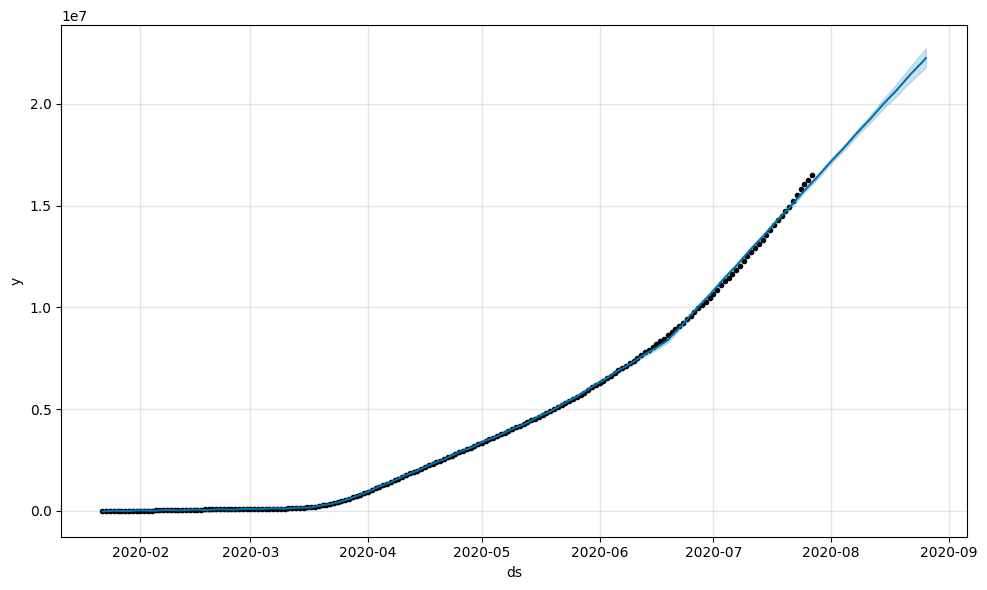

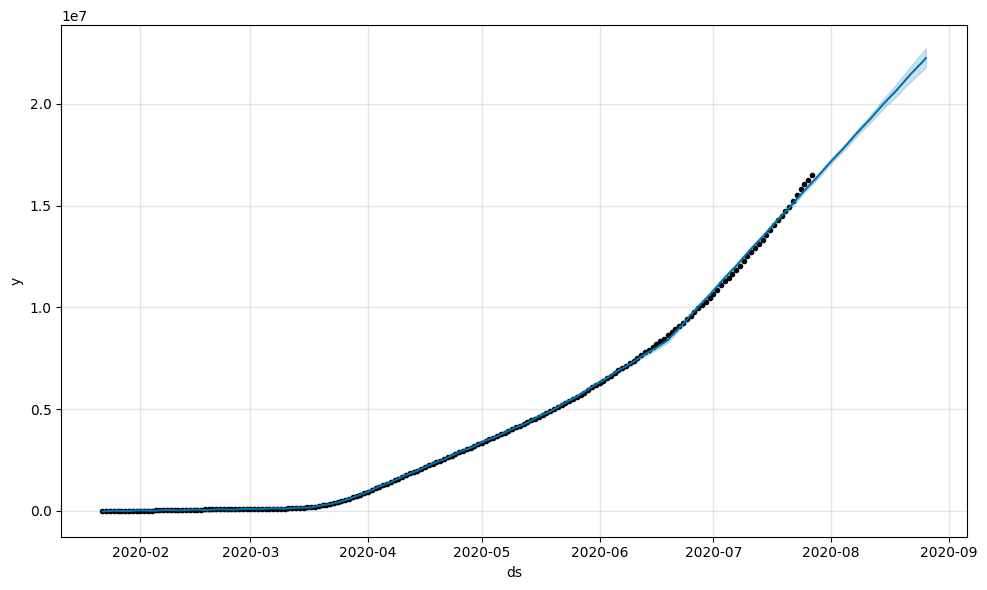

In [51]:
# Visualize Forecast
model.plot(forecast)

In [52]:
fig = px.line(forecast,x='ds',y='yhat',title='Global Covid-19 Forecast (Next 30 Days)')
fig.show()

In [53]:
#merge actual + predicted
merged = forecast[['ds','yhat']].merge(global_trend,left_on='ds',right_on='Date',how='left')
fig = px.line(merged,x='ds',y=['yhat','Confirmed'],title='Global Covid-19 Forecast vs Actual Predicted Cases')
fig.show()